In [ ]:
from __future__ import annotations

import json
import sys
from pathlib import Path
from typing import Any
import pandas as pd
import re

def load_json(path: Path) -> dict[str, Any] | None:
    if not path.exists():
        print(f"ERROR: file not found: {path}", file=sys.stderr)
        return None
    with path.open(encoding="utf-8") as f:
        return json.load(f)


def _preview(text: str | None, limit: int = 100) -> str:
    if text is None:
        return "<missing>"
    text = text.strip()
    return text if len(text) <= limit else text[:limit] + "..."


def levenshtein_distance(s1: str, s2: str) -> int:
    """Calculates the Levenshtein distance between two strings."""
    if len(s1) < len(s2):
        return levenshtein_distance(s2, s1)

    if len(s2) == 0:
        return len(s1)

    previous_row = list(range(len(s2) + 1))

    for i, c1 in enumerate(s1):
        current_row = [i + 1]
        for j, c2 in enumerate(s2):
            insertions = previous_row[j + 1] + 1
            deletions = current_row[j] + 1
            substitutions = previous_row[j] + (c1 != c2)
            current_row.append(min(insertions, deletions, substitutions))
        previous_row = current_row

    return previous_row[-1]

def normalize_text(text: str) -> str:
    """Chuẩn hóa văn bản để tính toán CER (chữ thường, loại bỏ khoảng trắng thừa)."""
    if text is None:
        return ""
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def cer(pred: str, gt: str) -> float:
    """Tính toán Character Error Rate (CER) dựa trên khoảng cách Levenshtein."""
    if not gt
        return 0.0 if not pred else 1.0
    distance = levenshtein_distance(pred, gt)
    return distance / len(gt)

# Ngưỡng độ chính xác cho báo cáo
ACC_THRESHOLDS = [0.0, 0.02, 0.05, 0.10]

def evaluate(gt_texts: list[str], pred_texts: list[str]) -> tuple[dict, pd.DataFrame]:
    """Đánh giá hiệu suất dự đoán so với ground truth."""
    n = len(gt_texts)
    cer_sum = 0.0
    acc_counts = {t: 0 for t in ACC_THRESHOLDS}
    exact_match = 0
    per_block = []

    max_len = max(len(gt_texts), len(pred_texts))

    for i in range(max_len):
        gt_raw = gt_texts[i] if i < len(gt_texts) else ""
        pred_raw = pred_texts[i] if i < len(pred_texts) else ""

        gt_norm = normalize_text(gt_raw)
        pred_norm = normalize_text(pred_raw)

        c = cer(pred_norm, gt_norm)
        cer_sum += c
        for t in ACC_THRESHOLDS:
            if c <= t:
                acc_counts[t] += 1
        if pred_norm == gt_norm:
            exact_match += 1
        per_block.append({"idx": i, "CER": c, "gt_raw": gt_raw, "pred_raw": pred_raw})

    summary = {
        "blocks": n,
        "CER_macro": cer_sum / n if n > 0 else 0.0,
        **{f"Acc@{t:.2f}": acc_counts[t] / n if n > 0 else 0.0 for t in ACC_THRESHOLDS},
        "ExactMatch": exact_match / n if n > 0 else 0.0,
    }
    return summary, pd.DataFrame(per_block)


In [ ]:
gt_data_path = Path("A32_groundtruth.json")
gt_data = load_json(gt_data_path)
gt_texts = [block.get("text", "") for block in gt_data.get("blocks", [])] if gt_data else []

#(raw_ocr)
raw_ocr_data_path = Path("A32_raw.json")
raw_ocr_data = load_json(raw_ocr_data_path)
raw_ocr_texts = [block.get("text", "") for block in raw_ocr_data.get("blocks", [])] if raw_ocr_data else []

#(fixed_ocr)
fixed_ocr_data_path = Path("A32_fix_ocr.json")
fixed_ocr_data = load_json(fixed_ocr_data_path)
fixed_ocr_texts = [block.get("text", "") for block in fixed_ocr_data.get("blocks", [])] if fixed_ocr_data else []

preds = {
    "groundtruth_baseline": gt_texts,
    "raw_ocr": raw_ocr_texts,
    "fixed_ocr": fixed_ocr_texts
}

all_summary = {}
all_per_block = {}

for name, texts in preds.items():
    summary, df = evaluate(gt_texts, texts)
    all_summary[name] = summary
    all_per_block[name] = df

summary_df = pd.DataFrame(all_summary).T
summary_df = summary_df[["blocks", "CER_macro", "Acc@0.00", "Acc@0.02", "Acc@0.05", "Acc@0.10", "ExactMatch"]]
summary_df.sort_values("CER_macro", inplace=True)

print("Báo cáo tổng hợp:")
display(summary_df)

Báo cáo tổng hợp:


,blocks,CER_macro,Acc@0.00,Acc@0.02,Acc@0.05,Acc@0.10,ExactMatch
groundtruth_baseline,560.0,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
fixed_ocr,560.0,0.001559,0.917857,0.978571,0.987500,0.998214,0.917857
raw_ocr,560.0,0.002197,0.901786,0.967857,0.983929,0.992857,0.901786


### Giải thích kết quả

*   **blocks**: Tổng số lượng block được so sánh.
*   **CER_macro**: Character Error Rate trung bình (càng thấp càng tốt). Đây là tỷ lệ ký tự bị lỗi so với tổng số ký tự trong dữ liệu gốc.
*   **Acc@0.00**: Tỷ lệ các block có CER bằng 0 (khớp chính xác).
*   **Acc@0.02, Acc@0.05, Acc@0.10**: Tỷ lệ các block có CER nhỏ hơn hoặc bằng 2%, 5%, 10% tương ứng. Đây là các ngưỡng để đánh giá mức độ chính xác chấp nhận được.
*   **ExactMatch**: Tỷ lệ các block khớp chính xác hoàn toàn (sau khi chuẩn hóa văn bản).

Dựa trên bảng trên:

*   **CER_macro (Character Error Rate trung bình):**
    *   `fixed_ocr`: `0.0016`
    *   `raw_ocr`: `0.0022`
    
    **Nhận xét:** `fixed_ocr` hiện đang có CER_macro thấp hơn `raw_ocr`, cho thấy `fixed_ocr` có ít lỗi ký tự hơn trong tổng thể.

*   **Acc@0.00 (Tỷ lệ khớp chính xác hoàn toàn):**
    *   `fixed_ocr`: `91.79%`
    *   `raw_ocr`: `90.18%`

    **Nhận xét:** `fixed_ocr` cũng có tỷ lệ khớp chính xác hoàn toàn cao hơn `raw_ocr`.

**Kết luận chung:**

Dựa trên cả chỉ số CER_macro và ExactMatch, **`fixed_ocr` đang cho thấy hiệu suất tốt hơn** so với `raw_ocr` trong phiên bản so sánh hiện tại.

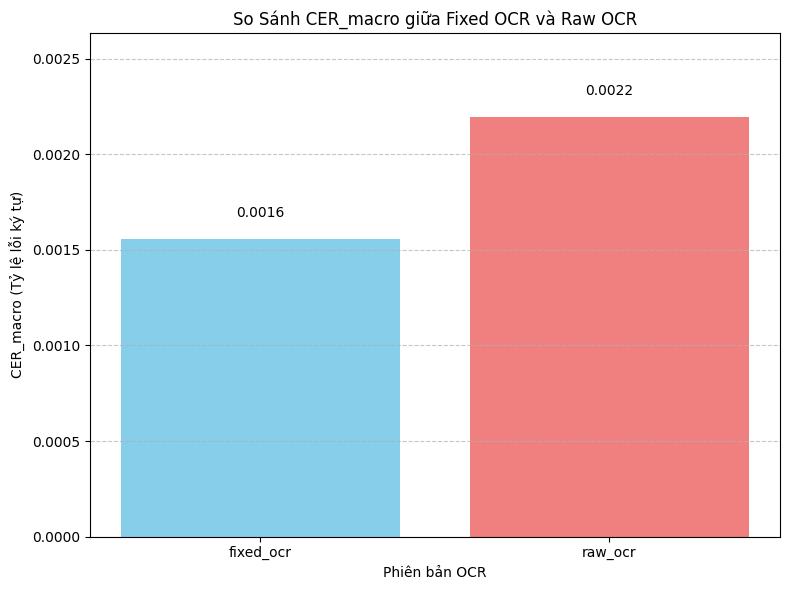

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Lấy dữ liệu CER_macro cho fixed_ocr và raw_ocr từ summary_df
cer_data = summary_df.loc[['fixed_ocr', 'raw_ocr']][['CER_macro']].copy()

# Tạo một cột mới cho tên phiên bản OCR để dễ dàng vẽ biểu đồ
cer_data['OCR_Version'] = cer_data.index

# Đặt lại chỉ mục để OCR_Version trở thành một cột thông thường
cer_data = cer_data.reset_index(drop=True)

# Tạo biểu đồ cột
fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(cer_data['OCR_Version'], cer_data['CER_macro'], color=['skyblue', 'lightcoral'])

# Thêm giá trị lên trên mỗi cột
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.0001, round(yval, 4),
            ha='center', va='bottom', fontsize=10)

ax.set_title('So Sánh CER_macro giữa Fixed OCR và Raw OCR')
ax.set_xlabel('Phiên bản OCR')
ax.set_ylabel('CER_macro (Tỷ lệ lỗi ký tự)')
ax.set_ylim(0, max(cer_data['CER_macro']) * 1.2) # Đặt giới hạn trục y để có không gian cho nhãn
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Các block có CER cao nhất trong `fixed_ocr`

Để kiểm tra chi tiết những lỗi sai, chúng ta sẽ xem xét các block có chỉ số CER cao nhất (tức là nhiều lỗi ký tự nhất) trong file `A32_fix_ocr.json` so với `A32_groundtruth.json`.

In [ ]:
fixed_ocr_detailed_df = all_per_block["fixed_ocr"]

filtered_fixed_ocr_df = fixed_ocr_detailed_df[fixed_ocr_detailed_df['CER'] > 0]

sorted_filtered_fixed_ocr_df = filtered_fixed_ocr_df.sort_values(by='CER', ascending=False)

output_csv_path = "fixed_ocr_high_cer_blocks.csv"
sorted_filtered_fixed_ocr_df.to_csv(output_csv_path, index=False)

print(f"Tất cả các block của fixed_ocr có CER > 0 đã được sắp xếp và lưu vào '{output_csv_path}' để bạn kiểm tra lỗi.")

Tất cả các block của fixed_ocr có CER > 0 đã được sắp xếp và lưu vào 'fixed_ocr_high_cer_blocks.csv' để bạn kiểm tra lỗi.
